In [ ]:
#created on 17/04/2026 by James McLoughlin

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # silences future development warninigs
# import cartopy.crs as ccrs
# import earthaccess
import geopandas as gpd
# import matplotlib.pyplot as plt
import numpy as np
np.seterr(divide='ignore', invalid='ignore') # silence maths warnings (0/0 or X/0) globally
# import os
import pandas as pd
from pathlib import Path
import rasterio as rio
import rasterio.merge
# from rasterio.enums import Resampling
# from rasterio import features
# from rasterio.features import shapes
# from rasterio.features import sieve
from rasterio.merge import merge
# from rasterio.plot import show
from rasterio.windows import from_bounds
# from rasterstats import zonal_stats
import rioxarray
# import shapely
# from shapely.geometry import shape
# from shapely.geometry import Polygon
# from shapely import affinity
import xarray as xr
# from xrspatial import hillshade



#from cartopy.crs import PlateCarree


In [2]:
def get_bands_by_satellite(target_colours):
    print(f"Creating dataset dataframe, searching for band files...")
    records = []

    # Map colors to band numbers based on the Satellite ID prefix
    # LT04/05 = Landsat 4/5 TM; LE07 = Landsat 7 ETM+; LC08/09 = Landsat 8/9 OLI
    band_config = {
    "LT05":{"B1":"BLUE", "B2":"GREEN", "B3":"RED", "B4":"NIR", "B5":"SWIR1", "B7":"SWIR2"},
    "LT07":{"B1":"BLUE", "B2":"GREEN", "B3":"RED", "B4":"NIR", "B5":"SWIR1", "B6":"TIR", "B7":"SWIR2" },
    "LC08":{"B1":"COAST/AERO", "B2":"BLUE", "B3":"GREEN", "B4":"RED", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"},
    "LC09":{"B1":"COAST/AERO", "B2":"BLUE", "B3":"GREEN", "B4":"RED", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"}
}
    for folder in PATHS["landsat_images"].iterdir():
        if folder.is_dir():
            for file in folder.glob("*_SR_B*.TIF"):
                parts = file.name.split("_")
                sat_id = parts[0][:4]
                band_id = parts[-1].replace(".TIF", "")
                if band_config[sat_id][band_id] in target_colours:
                    records.append({
                        "satellite": sat_id,
                        "path_row": parts[2],
                        "year": parts[3][:4],
                        "band": band_id,
                        "colour": band_config[sat_id][band_id],
                        "filename": file.name,
                        "path": str(file)
                    })
    print("Dataset dataframe created")
    return pd.DataFrame(records)

In [3]:
def create_mosaic(file_list, out_path, dtype=None): 
    # 1. Get CRS from the first file for comparison with other files
    with rio.open(file_list[0]) as src:
        target_crs = src.crs
        out_meta = src.profile.copy()

    # 2. Compare othes files against ref CRS and reproject if they don't match
    processed_list = []
    for f in file_list:
        with rio.open(f) as src:
            if src.crs != target_crs:
                print(f"Fixing CRS for: {f.name}")
                processed_list.append(fix_projection(f, target_crs))
            else:
                processed_list.append(f)

    # 3. Merge images, return the new array and new spatial transform
    print(f"Mosaicking files...")
    mosaic, out_trans = merge(processed_list, nodata=0)

    # 4. Update the metadata with mosiac dimensions and transform
    bands, height, width = mosaic.shape
    out_meta.update({
        "height": height, 
        "width": width, 
        "transform": out_trans, 
        "nodata": 0,
        "dtype": dtype or out_meta['dtype'] # And here
    })

    # 5. Save mosaic and full metadata to file
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rio.open(out_path, "w", **out_meta) as dest:
        dest.write(mosaic)

    print(f"Mosaic saved: {out_path.name}")

In [ ]:
# def fix_projection(in_path, target_crs):
#     """Reprojects a file to the target CRS and returns the new path."""
#     out_path = in_path.parent / f"reprojected_{in_path.name}"
#     with rio.open('data_files/NI_Mosaic.tif') as src:
#     transform, width, height = rio.warp.calculate_default_transform(
#             src.crs, dst_crs, src.width, src.height, *src.bounds)
    
#     with rio.open(in_path) as src:
#         transform, width, height = calculate_default_transform(
#             src.crs, target_crs, src.width, src.height, *src.bounds)
#         meta = src.profile.copy()
#         meta.update({'crs': target_crs, 'transform': transform, 'width': width, 'height': height})

#         with rio.open(out_path, 'w', **meta) as dst:
#             reproject(source=rio.band(src, 1), destination=rio.band(dst, 1),
#                       src_transform=src.transform, src_crs=src.crs,
#                       dst_transform=transform, dst_crs=target_crs,
#                       resampling=Resampling.nearest)
#     return out_path

In [ ]:
# def reproject_raster(src, dst_crs):
#     transform, width, height = rio.warp.calculate_default_transform(
#         src.crs, dst_crs, src.width, src.height, *src.bounds
#     )

#     kwargs = src.meta.copy()
#     kwargs.update({
#         "crs": dst_crs,
#         "transform": transform,
#         "width": width,
#         "height": height
#     })

#     data = np.empty((src.count, height, width), dtype=src.dtypes[0])

#     for i in range(1, src.count + 1):
#         reproject(
#             source=rio.band(src, i),
#             destination=data[i-1],
#             src_transform=src.transform,
#             src_crs=src.crs,
#             dst_transform=transform,
#             dst_crs=dst_crs,
#             resampling=Resampling.nearest
#         )

#     return data, kwargs

In [8]:
def ndi_and_clipping(yr, border_gdf):
    """
    1. Loads windowed mosaic bands for the year.
    2. Stacks them into an Xarray Dataset.
    3. Clips the stack to the jagged park boundary.
    4. Calculates and saves each NDI index.
    """
    raster_data = {}
    win_meta = None
    
    for band in ANALYSIS_COLOURS:
        file = PATHS["mosaics"] / f"{yr}_{band}_mosaic.tif"
        with rio.open(file) as src:
            if border_gdf.crs != src.crs:
                border_gdf = border_gdf.to_crs(src.crs)
                
            window = from_bounds(*border_gdf.total_bounds, transform = src.transform)
            raster_data[band] = xr.DataArray(src.read(1,window=window).astype("float32"), dims=("y","x"))#flaot32 added here to support the  ndvi calulations later on
            if win_meta is None:
                win_meta = {'crs':src.crs, 'transform':src.window_transform(window)}

    ds = xr.Dataset(raster_data)
    ds = ds.rio.write_crs(win_meta['crs']).rio.write_transform(win_meta['transform'])

    ds_clipped = ds.rio.clip(border_gdf.geometry, drop =True)
            
    for NDI in ANALYSIS_TASKS:
        b1_name, b2_name = INDEX_TO_BANDS[NDI]
        print(b1_name, b2_name)
        b1, b2 = ds_clipped[b1_name], ds_clipped[b2_name]   

        result = (b1 - b2) / (b1 + b2)
        result = result.where(~np.isinf(result)) # Replaces Inf with NaN
        
        ndi_out = PATHS["ndi"] / f"{yr}_{NDI}.tif"
        result.rio.to_raster(ndi_out, nodata=np.nan)
        print(f"{yr}_{NDI} saved")
    del result, ds_clipped, raster_data


In [9]:
# --- 1. User Inputs ---
base = Path("C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped") # insert path of base directory into brackets, eg. Path(<base_folder_location>)
boundary_file = Path("C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped/Boundary Files/national_park_boundary.shp")

#select desired display and analysis: 0 = not wanted, 1 = wanted.
USER_OPTIONS = {
    "TRUE_COLOUR": 1,
    "FALSE_COLOUR": 0,
    "NDVI": 1,
    "NDWI": 1,
    "NDSI": 0,
}


# --- 2. Creating folder structure ---
PATHS = {
    "landsat_images" : base / "Landsat_Images",
    "ndi": base / "NDI Images",
    "mosaics": base / "Mosaics",
    "boundaries": base / "Boundary Files",
    "earthaccess": base / "EarthAccess",
}
for p in PATHS.values(): p.mkdir(parents=True, exist_ok=True)
print("Directories checked/created")


# --- 3. Determine colour bands requried for selected disaply / analysis 
#dictionary describes relationship between actions and bands
INDEX_TO_BANDS = {
    "TRUE_COLOUR" : ["BLUE", "GREEN", "RED"],
    "FALSE_COLOUR" : ["GREEN","RED","NIR"],
    "NDVI": ["RED", "NIR"],
    "NDWI": ["GREEN", "NIR"],
    "NDSI": ["GREEN", "SWIR1"]
}

DISPLAY_TASKS = [task for task in ["TRUE_COLOUR", "FALSE_COLOUR"] if USER_OPTIONS.get(task)]
display_colours_raw = list({band for key in DISPLAY_TASKS for band in INDEX_TO_BANDS[key]})
colour_order = ["COAST/AERO","BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
DISPLAY_COLOURS = [b for b in colour_order if b in display_colours_raw]
ANALYSIS_TASKS = [task for task in ["NDVI", "NDWI", "NDSI"] if USER_OPTIONS.get(task)]
ANALYSIS_COLOURS = list({band for key in ANALYSIS_TASKS for band in INDEX_TO_BANDS[key]})
ALL_COLOURS = list(set(DISPLAY_COLOURS + ANALYSIS_COLOURS))



# --- 4. Build DataFrame of raster images needed for display / analysis activities ---
df = get_bands_by_satellite(ALL_COLOURS)
df.to_csv(PATHS["landsat_images"] / "bands_dataframe.csv", index = False)


# --- 5. Mosaicking Rasters ---
years = df["year"].unique()
for yr in years:
    for colr in ALL_COLOURS:
        file_list = df[(df["year"] == yr) & (df["colour"] == colr)]["path"].tolist()
        dst_path = PATHS["mosaics"] / f"{yr}_{colr}_mosaic.tif"
        create_mosaic(file_list, dst_path)


#--- 6. NDVI analysis ---

border_gdf = gpd.read_file(boundary_file)
for yr in years:
    ndi_and_clipping(yr, border_gdf)

print("--- All Tasks Completed ---")





Directories checked/created
Creating dataset dataframe, searching for band files...
Dataset dataframe created
Mosaicking files...
Mosaic saved: 2020_BLUE_mosaic.tif
Mosaicking files...
Mosaic saved: 2020_RED_mosaic.tif
Mosaicking files...
Mosaic saved: 2020_NIR_mosaic.tif
Mosaicking files...
Mosaic saved: 2020_GREEN_mosaic.tif
RED NIR
2020_NDVI saved
GREEN NIR
2020_NDWI saved
--- All Tasks Completed ---


In [ ]:
def acquiring_DEMS

outline = gpd.read_file(boundary_file).to_crs(epsg = 4326).union_all()
search_area = outline.minimum_rotated_rectangle
search_area = shapely.geometry.polygon.orient(search_area, sign=1)
#getting dem data from earthaccess
earthaccess.login(strategy='netrc')
results = earthaccess.search_data(
    short_name = 'ASTGTM',
    polygon = search_area.exterior.coords
)
output_folder = paths["earthaccess"]
download_file = earthaccess.download(results, output_folder)

In [ ]:
### Clipping DEM mosiac
dem_file = paths["earthaccess"] / "DEM_merged.TIF"
rds = rioxarray.open_rasterio(dem_file)
gdf = gpd.read_file(boundary_file).to_crs(rds.rio.crs)
clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
clipped_dem = paths["clipped"] / "clipped DEM.tif"
clipped.rio.to_raster(clipped_dem)

In [ ]:
# def clipping(input_path, output_path, boundary_file):
#     """Clips a raster file using a boundary polygon and saves the result."""
#     rds = rioxarray.open_rasterio(input_path)     # Open raster
#     gdf = gpd.read_file(boundary_file).to_crs(rds.rio.crs) # Open boundary and reproject to raster
    
#     # Perform clip and save
#     clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
#     output_path.parent.mkdir(parents=True, exist_ok=True)
#     clipped.rio.to_raster(output_path)
    
#     print(f"Clipped: {output_path.name}")
#     return clipped

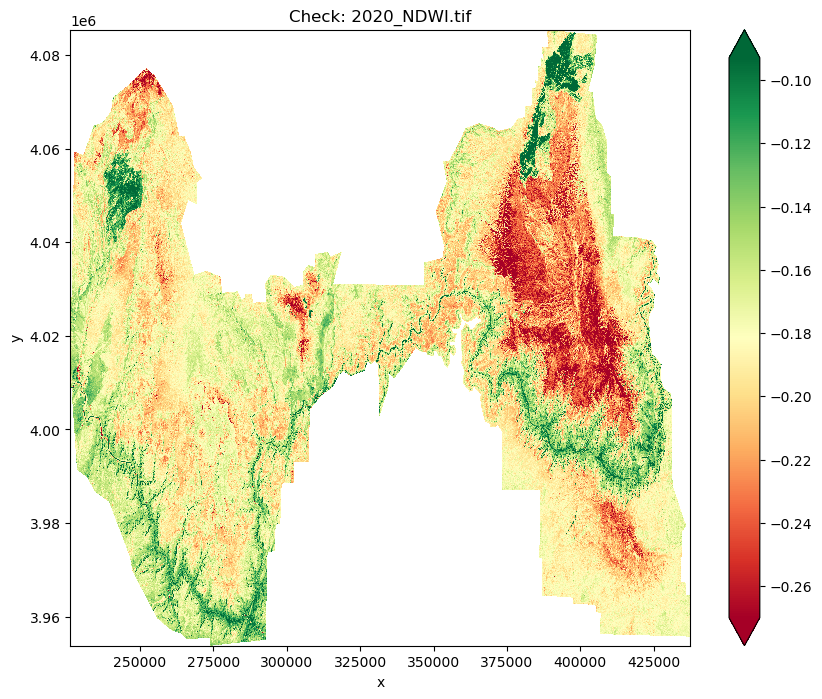

Max NDVI: 0.25951001048088074
Min NDVI: -0.48235493898391724


In [11]:
import matplotlib.pyplot as plt
import rioxarray

# Pick one of your generated files
test_file = PATHS["ndi"] / "2020_NDWI.tif"

# Open it
rds = rioxarray.open_rasterio(test_file)

# Plot it
plt.figure(figsize=(10, 8))
rds.plot(cmap="RdYlGn", robust=True)#, vmin=-1, vmax=1) # Standard NDVI colors
plt.title(f"Check: {test_file.name}")
plt.show()

# Quick Stats check
print(f"Max NDVI: {rds.max().values}")
print(f"Min NDVI: {rds.min().values}")

In [ ]:
def segmenting_dem
with rio.open(clipped_dem) as src:
    dem = src.read(1)
    meta = src.meta.copy()
    dem_clean = np.nan_to_num(dem, nan=-9999) #replace NaNs with -9999
    zones = (dem_clean // 500).astype(np.int32) #split elevtion range into 500m intervals. Floor divions used to crete discrete steps
    transform = src.transform
    crs = src.crs

polygons_list = [] # Create an empty list for elevation zone polygons

# Loop through the shapes found in the elevation zones and detemine geometry (s) and value (v)
for s, v in features.shapes(zones, transform=transform):
    if v != src.nodata:     #Skip areas of empty space
        
        # Build polygon dictionary in GeoPandas format and add to list
        feature_dict = {'properties': {'elev_zone': v}, 'geometry': s}
        polygons_list.append(feature_dict)

# Now turn that list into a GeoDataFrame
gdf_segments = gpd.GeoDataFrame.from_features(polygons_list, crs="EPSG:4326")
gdf_segments = gdf_segments.to_crs("EPSG:26912")

# # results = (
# #     {'properties': {'elev_zone': v}, 'geometry': s}
# #     for i, (s, v) in enumerate(features.shapes(zones, transform=transform))
# #     if v != src.nodata  # Ignore NoData areas
# # )

In [ ]:
def zonal_statistics
ndvi_path = paths["ndi"] / "2020_NDVI.tif" # path for NDVI image to be cmopared against segmented DEM
stats = zonal_stats(gdf_segments, str(ndvi_path), stats="mean", all_touched=True) # Runing zonal statistics on ndvi_path
gdf_segments['mean_ndvi'] = [s['mean'] for s in stats] # Attaching results to GeoDataFrame
gdf_results = gdf_segments.dropna(subset=['mean_ndvi']) # cleaning up empty or NoData zones

In [ ]:
# creating composite images
def normalize(band):
    band_max, band_min = band.max(), band.min()
    norm = ((band - band_min)/(band_max - band_min))
    return norm
    
def composite_images(comp_types, yr, input_path, destination_path):
        for comp in comp_types:
            path1 = paths["mosaics"] / f"{yr}_{index_to_bands[comp][0]}_mosaic.tif"
            path2 = paths["mosaics"] / f"{yr}_{index_to_bands[comp][1]}_mosaic.tif"
            path3 = paths["mosaics"] / f"{yr}_{index_to_bands[comp][2]}_mosaic.tif"
    
        with rio.open(path1) as src1, rio.open(path2) as src2, rio.open(path3) as src3:
            colr1 = src1.read(1)
            colr2 = src2.read(1)
            colr3 = src3.read(1)
            out_meta = src1.meta.copy()
            ncolr1 = (normalize(colr1) * 255).astype(np.uint8)
            ncolr2 = (normalize(colr2) * 255).astype(np.uint8)
            ncolr3 = (normalize(colr3) * 255).astype(np.uint8)
            
            out_meta.update({
                "driver": "GTiff",
                "count": 3,
                "dtype": "uint8",
                "compress": "lzw"
            })
            out_filename = paths["mosaics"] / f"{yr}_{comp}_composite.tif"

            with rio.open(out_filename, 'w', **out_meta) as dst:
                dst.write(ncolr3, 1) # Red channel (or first selected band)
                dst.write(ncolr2, 2) # Green channel
                dst.write(ncolr1, 3) # Blue channel
                
            print(f"Saved: {out_filename}")

In [ ]:
def hillshade:
dem_path = paths["earthaccess"] / "DEM_merged.TIF"
with rio.open(dem_path) as src:
    dem = src.read(1)
    out_meta = src.meta.copy()
elevation_da = xr.DataArray(dem, dims=['y', 'x'])
illuminated = hillshade(elevation_da, azimuth=315, angle_altitude=45)
out_filename = paths["mosaics"] / "hillshade.tif"
with rio.open(out_filename, 'w', **out_meta) as dst:
    dst.write(illuminated, 1)
print('data saved')                
#plt.imshow(illuminated, cmap='Greys')
#plt.show

In [ ]:







# --- 5. Mosaicking DEM ---
dem_files = [fn for fn in download_file if 'dem.tif' in fn.name]
dem_out = paths["earthaccess"] / "DEM_merged.TIF"
dem_meta = create_mosaic(dem_files, dem_out, dtype='float32')

# --- 6. Clipping DEM ---
dem_src = paths["earthaccess"] / "DEM_merged.TIF"
dem_dst = paths["clipped"] / "clipped DEM.tif"
clipped_dem_data = clip_raster(dem_src, dem_dst, boundary_file)

# --- 7. Segmenting DEM ---
# --- 8. Zonal Statistics OF Rasters ---

# --- 9. Displaying Results ---

for yr in landsat_df["year"].unique():
    composite_images(display_tasks, yr)
    
comp_path = paths["mosaics"] / "2020_TRUE_COLOUR_composite.tif"
hill_path = paths["mosaics"] / "hillshade.tif"
boundary = gpd.read_file(boundary_file)

with rio.open(comp_path) as src:
    img_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    rgb_composite = src.read([1,2,3]).transpose(1,2,0)/255
    
boundary = boundary.to_crs(src.crs)
gdf_results = gdf_results.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb_composite, extent=img_extent)
ax.imshow(hillshade, cmap='gray', alpha=0.4, extent=img_extent)
boundary.plot(ax=ax, facecolor='none', edgecolor='orange', linewidth=1)
gdf_results.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)

ax.set_axis_off()
plt.show()

In [ ]:
### Clipping rasters
def clipping(df, colour_bands, ref_poly):
    print("Image clipping started")
    for yr in df["year"].unique():
        for colr in colour_bands:
            scene = dirs["mosaics"] / f"{yr}_{colr}_mosaic.tif"
            # landsat_scene = df[(df["colour"] == colr) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
            rds = rioxarray.open_rasterio(scene)
            gdf = gpd.read_file(ref_poly).to_crs(rds.rio.crs)
            clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
            clipped_out = dirs["clipped"] / f"{yr}_{colr}_clipped.tif"
            clipped.rio.to_raster(clipped_out)
            print(f"{yr} {colr} mosaic clipped and saved") 
    print("All clippling completed")

In [ ]:
# Plots the mosaicked DEM layer
#data_crs=ccrs.PlateCarree()
fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.imshow(dem, cmap='gray', transform=ccrs.PlateCarree(), extent=[xmin, xmax, ymin, ymax]) # display band 0 as a grayscale image, stretched between 0 and 400
ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())
plt.show()

In [ ]:
# adding buffer to park boundary to avoid clipping river only
all_polygons = []
park_poly_file = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/national_park_boundary.shp"
park_poly = gpd.read_file(park_poly_file).to_crs(epsg = 26912).union_all()
park_ploy_buffered = park_poly.buffer(1000)
park_buff_gdf = gpd.GeoDataFrame(geometry=[park_ploy_buffered],crs=('EPSG:26912'))
park_ref_out = polygons / "buffered_park_polygon.gpkg"
park_buff_gdf.to_file(park_ref_out, driver ="GPKG")

In [ ]:
#function for isolationg and joing the river polygons
def merging_polygons(poly_gdf, ref_poly):
    combined_gdf = pd.concat(poly_gdf)
    
    #Apply buffer to bridge gaps between tiles
    combined_gdf['geometry'] = combined_gdf.geometry.buffer(100) 
    
    #Weld small localised pieces together
    merged = combined_gdf.union_all()
    
    # Searate main bodies into distinct polygons
    main_polygons = gpd.GeoSeries([merged], crs="EPSG:26912").explode(index_parts=False)
    main_polygons_gdf = gpd.GeoDataFrame(geometry=main_polygons)
   
    # Keep only polygons that touch river reference
    # ensures small 'ilsnad' polyons in the river path are not omitted.
    ref_geom = gpd.read_file(ref_poly).to_crs("EPSG:26912").union_all()
    referenced_poly = main_polygons_gdf[main_polygons_gdf.intersects(ref_geom)]
   
    # 5. Shrink it back (undo the buffer) to get original river width
    referenced_poly['geometry'] = referenced_poly.geometry.buffer(-100)
    buffered_poly = referenced_poly.copy()
    buffered_poly['geometry'] = buffered_poly.geometry.buffer(5000)

    poly_out = polygon_data / "Grand_Canyon_River.gpkg"
    buff_out = polygon_data / "Grand_Canyon_River_Buffer_5000.gpkg"
    referenced_poly.to_file(poly_out, driver="GPKG")
    buffered_poly.to_file(buff_out, driver="GPKG")

In [ ]:
### function for making mask, binarising it, and converting to polygons
def mask_from_raster(year, pathrow, NDI):#, river_ref_path):
    poly_list = []
    file = NDI_data/f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        non_binary = src.read(1)
        mask = np.where(non_binary > -0.1 , 255 ,0).astype("uint8")
        cleaned_mask = sieve(mask,50)
        out_meta = src.meta.copy()
        out_meta.update(dtype = "uint8", nodata = 0)
        mask_out = masks / f"{year}_{pathrow}_{NDI}.tif"
        
        with rio.open(mask_out, "w", **out_meta) as dst:
            dst.write(cleaned_mask,1)

    file = mask_data / f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        tile = src.read(1).astype("int16")
        out_meta = src.meta.copy()
        mask_shapes = features.shapes(
            tile,
            mask = tile > 0,
            transform = out_meta['transform']
        )
    # The corrected list comprehension
    polygons = [
    {'geometry':shape(s),'properties':{'id': i}}
     for i, (s,v) in enumerate(mask_shapes)
    ]
              
    gdf = gpd.GeoDataFrame.from_features(polygons, crs=out_meta['crs'])
    return gdf